In [1]:
!pip -q install pandas numpy matplotlib seaborn scipy openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
networks = ["DMN", "Salience", "FPN", "Limbic", "Visual", "Somatomotor"]

acute = {
    "DMN": -0.72,
    "Salience": 0.50,
    "FPN": 0.30,
    "Limbic": 0.38,
    "Visual": 0.18,
    "Somatomotor": 0.06
}

rows = []

for net in networks:
    acute_val = acute[net] + np.random.normal(0, 0.03)
    post_val = acute_val * np.random.uniform(0.15, 0.65)
    rows.append([net, acute_val, post_val])

df = pd.DataFrame(rows, columns=["network", "acute_delta", "postacute_delta"])
df

,network,acute_delta,postacute_delta
0,DMN,-0.705099,-0.363829
1,Salience,0.495852,0.222801
2,FPN,0.292975,0.052455
3,Limbic,0.372976,0.217478
4,Visual,0.227376,0.036447
5,Somatomotor,0.083023,0.052716


In [4]:
df["recovery_index"] = 1 - (
    np.abs(df["postacute_delta"]) / np.abs(df["acute_delta"])
)

df["trajectory"] = np.where(
    df["recovery_index"] >= 0.60,
    "normalized",
    "persistent"
)

df

,network,acute_delta,postacute_delta,recovery_index,trajectory
0,DMN,-0.705099,-0.363829,0.484003,persistent
1,Salience,0.495852,0.222801,0.550671,persistent
2,FPN,0.292975,0.052455,0.820958,normalized
3,Limbic,0.372976,0.217478,0.416912,persistent
4,Visual,0.227376,0.036447,0.839708,normalized
5,Somatomotor,0.083023,0.052716,0.365045,persistent


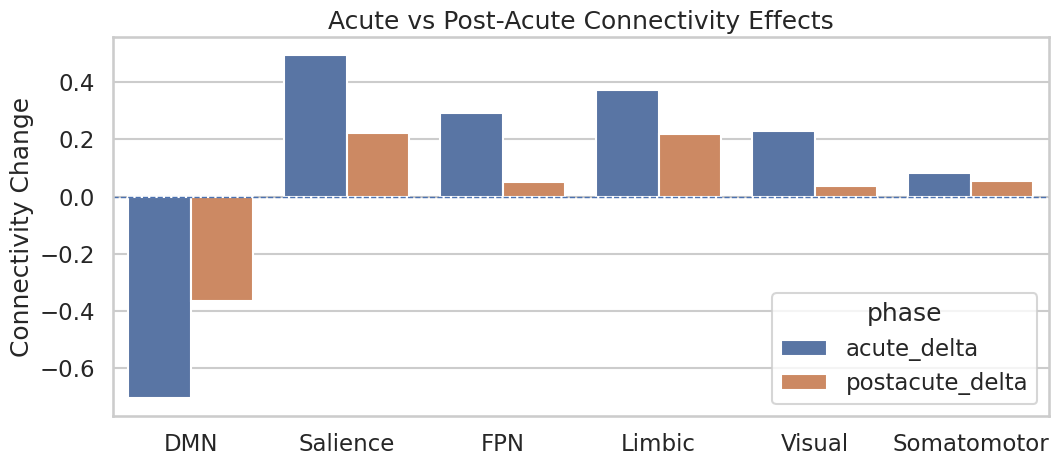

In [5]:
plot_df = df.melt(
    id_vars="network",
    value_vars=["acute_delta", "postacute_delta"],
    var_name="phase",
    value_name="connectivity_change"
)

plt.figure(figsize=(11,5))

sns.barplot(
    data=plot_df,
    x="network",
    y="connectivity_change",
    hue="phase"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("")
plt.ylabel("Connectivity Change")
plt.title("Acute vs Post-Acute Connectivity Effects")
plt.tight_layout()
plt.savefig("figures/03_acute_vs_postacute_barplot.png", dpi=300)
plt.show()

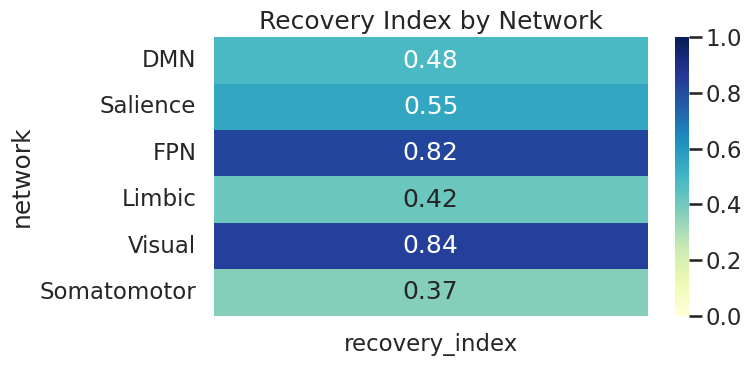

In [6]:
heat = df.set_index("network")[["recovery_index"]]

plt.figure(figsize=(8,4))

sns.heatmap(
    heat,
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1
)

plt.title("Recovery Index by Network")
plt.tight_layout()
plt.savefig("figures/03_recovery_index_heatmap.png", dpi=300)
plt.show()

In [7]:
df.to_csv("outputs/03_postacute_recovery_metrics.csv", index=False)

summary = df[["network", "trajectory"]]
summary

,network,trajectory
0,DMN,persistent
1,Salience,persistent
2,FPN,normalized
3,Limbic,persistent
4,Visual,normalized
5,Somatomotor,persistent
